# 3장. 컨볼루션과 차분방정식 — 시간영역 해석
## Convolution and Difference Equations: Time-Domain Analysis

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jwlee95/DSP_w_Python2026/blob/main/ch03_convolution_difference_equations/3장_컨볼루션과_차분방정식.ipynb)

> ⚠️ **참고**: 위 Colab 배지의 저장소 경로(`jwlee95/DSP_w_Python2026/.../ch03_...`)는 실제 GitHub 공개 저장소에 이 노트북을 최종 커밋한 뒤 실제 경로로 교체해야 하는 **플레이스홀더**입니다(구성안 관례).

『파이썬으로 배우는 디지털 신호처리 — 생체신호 응용까지』 3장 실습 노트북입니다.

- **대응 주차**: 3~4주차 (LTI 시스템의 시간영역 해석)
- 이 노트북은 이론(수식 유도) → 알고리즘(의사코드) → 파이썬 구현 → 시각화 → 응용 사례 → 연습문제의 순서로 구성되어 있으며, 코드 셀을 위에서부터 순서대로 실행하면 됩니다.
- 모든 코드는 외부 데이터셋 없이 합성 신호로 완결되므로, Colab에서 별도 파일 업로드 없이 바로 실행할 수 있습니다.


## 3.0 개요 (Overview)

2장에서는 이산 시스템이 가질 수 있는 네 가지 핵심 성질(선형성, 시불변성, 인과성, 안정성)을 정의하였습니다. 이 가운데 **선형성**과 **시불변성**을 동시에 만족하는 시스템을 **선형 시불변(LTI, Linear Time-Invariant) 시스템**이라 부르며, 디지털 신호처리 이론 전체가 사실상 이 LTI 시스템의 분석을 중심으로 전개됩니다.

> **LTI 시스템은 단 하나의 신호, 즉 단위임펄스응답(unit impulse response) $h[n]$만 알고 있으면 임의의 입력에 대한 출력을 완전히 예측할 수 있습니다.**

이것이 가능한 이유는 1장에서 정의한 단위 임펄스 $\delta[n]$를 이용하여 임의의 신호를 "시간이동된 임펄스들의 가중합"으로 분해할 수 있고, 선형성과 시불변성이 바로 이 분해와 시스템 통과 연산의 순서를 교환할 수 있게 해주기 때문입니다. 이 절차를 거쳐 도출되는 입출력 관계식이 바로 본 장의 핵심 주제인 **컨볼루션 합(convolution sum)**입니다.

3장은 다음의 순서로 전개됩니다.

- 3.1절: 임펄스 분해를 통해 컨볼루션 합을 직접 유도합니다.
- 3.2절: 컨볼루션 연산이 가지는 수학적 성질(교환법칙, 결합법칙, 분배법칙, 항등원)을 정리합니다.
- 3.3절: 컨볼루션을 손으로 계산하는 두 가지 표준적인 방법(그래픽적 방법과 표 작성법)을 다룹니다.
- 3.4절: LTI 시스템을 기술하는 또 다른 표준적인 도구인 **선형 상수계수 차분방정식**을 소개하고, 컨볼루션과의 관계를 확인합니다.
- 3.5~3.7절: 컨볼루션 합을 수치적으로 계산하는 알고리즘을 설계하고, 파이썬으로 구현하여 시각화합니다.
- 3.8절: 이동평균(moving average) 필터를 이용한 잡음 제거 응용을 다룹니다.


## 3.1 임펄스 분해와 LTI 시스템의 표현

### 3.1.1 신호의 임펄스 분해 (Impulse Decomposition of a Signal)

임의의 이산신호 $x[n]$은, 단위 임펄스 $\delta[n]$를 시간이동하고 척도변환한 신호들의 합으로 항상 정확하게 표현할 수 있습니다.

$$
x[n] = \sum_{k=-\infty}^{\infty} x[k]\,\delta[n-k] \tag{3.1}
$$

이 식이 성립하는 이유는 간단합니다. 임의의 고정된 인덱스 $n$에서, 합 안의 $\delta[n-k]$는 $k=n$일 때만 1이고 그 외의 모든 $k$에서는 0이 되므로, 우변의 합은 결국 $x[n]\cdot 1 = x[n]$이라는 한 개의 항만 남습니다. 즉 (3.1)은 항등식이며, 이를 신호의 **임펄스 분해(impulse decomposition)** 또는 **표본화 성질(sampling property)**이라 부릅니다.

**그림 3.1** 임펄스 분해 — 원신호와 가중 임펄스 성분의 비교


<p align="center">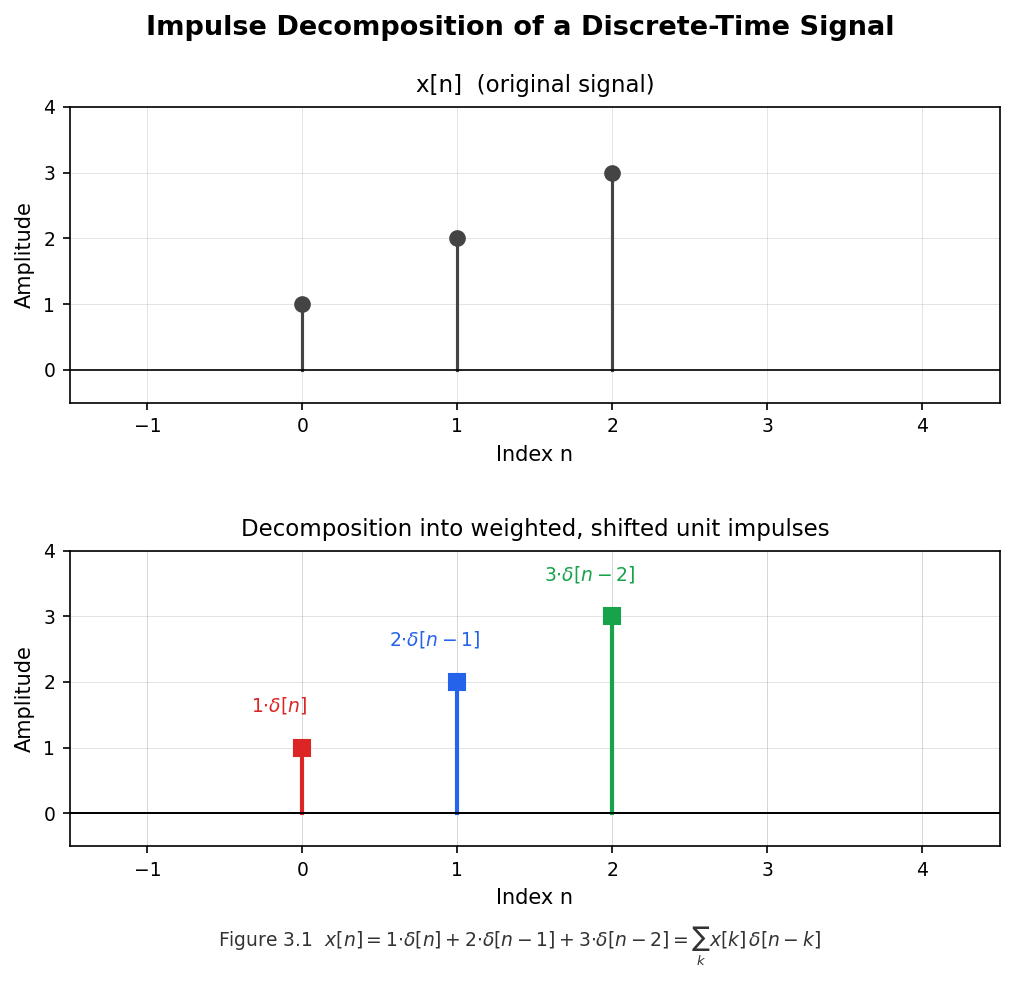</p>

### 3.1.2 LTI 시스템 출력의 유도 (Derivation of the Output of an LTI System)

(3.1)로 분해된 입력 $x[n]$을 LTI 시스템 연산자 $T[\cdot]$에 통과시켜 보겠습니다.

$$
y[n] = T\big[x[n]\big] = T\Big[\sum_{k=-\infty}^{\infty} x[k]\,\delta[n-k]\Big] \tag{3.2}
$$

**(1) 선형성의 적용 — 유한 부분합에서 출발**

먼저 $-N \le k \le N$ 구간의 항만 남긴 유한 부분합

$$
x_N[n] \triangleq \sum_{k=-N}^{N} x[k]\,\delta[n-k] \tag{3.3}
$$

을 정의합니다. 가산성을 적용하면,

$$
T\big[x_N[n]\big] = \sum_{k=-N}^{N} T\big[x[k]\,\delta[n-k]\big] \tag{3.4}
$$

균일성을 적용하면 상수 $x[k]$를 $T[\cdot]$ 바깥으로 빼낼 수 있습니다.

$$
T\big[x[k]\,\delta[n-k]\big] = x[k]\,T\big[\delta[n-k]\big] \tag{3.5}
$$

$$
T\big[x_N[n]\big] = \sum_{k=-N}^{N} x[k]\,T\big[\delta[n-k]\big] \tag{3.6}
$$

**(2) 무한합으로의 확장 — $N\to\infty$의 극한**

$$
y[n] = T\Big[\lim_{N\to\infty} x_N[n]\Big] \;\overset{?}{=}\; \lim_{N\to\infty} T\big[x_N[n]\big] = \sum_{k=-\infty}^{\infty} x[k]\,T\big[\delta[n-k]\big] \tag{3.7}
$$

> **참고**: $\overset{?}{=}$는 이 등식이 무조건 성립하는 것이 아니라, 신호가 절대합 가능(absolutely summable)하다는 등의 수렴 조건이 만족된다는 전제 위에서만 성립함을 강조하는 표기입니다. 본 교재에서 다루는 모든 LTI 시스템은 이 전제를 만족한다고 가정합니다.

$$
y[n] = \sum_{k=-\infty}^{\infty} x[k]\,T\big[\delta[n-k]\big] \tag{3.8}
$$

**(3) 시불변성의 적용**

단위임펄스응답을 $h[n] \triangleq T[\delta[n]]$로 정의하면, 시불변성에 의해

$$
T\big[\delta[n-k]\big] = h[n-k] \tag{3.11}
$$

**(4) 최종 결과의 조립**

$$
\boxed{\,y[n] = \sum_{k=-\infty}^{\infty} x[k]\,h[n-k] \triangleq x[n] * h[n]\,} \tag{3.12}
$$

이 식이 바로 **컨볼루션 합(convolution sum)**이며, 기호 `*`로 표기합니다. **임의의 LTI 시스템의 입출력 관계는 그 시스템의 단위임펄스응답 $h[n]$ 하나만으로 완전히 결정됩니다.**


## 3.2 컨볼루션의 정의와 성질

$$
y[n] = x[n] * h[n] = \sum_{k=-\infty}^{\infty} x[k]\,h[n-k] \tag{3.13}
$$

- **교환법칙**: $x[n] * h[n] = h[n] * x[n]$ — 변수치환 $m=n-k$로 증명됩니다.
- **결합법칙**: $\big(x[n]*h_1[n]\big)*h_2[n] = x[n]*\big(h_1[n]*h_2[n]\big)$ — 두 LTI 시스템을 직렬(cascade) 연결한 등가 시스템은 $h_1[n]*h_2[n]$ 하나로 표현됩니다.
- **분배법칙**: $x[n]*\big(h_1[n]+h_2[n]\big) = x[n]*h_1[n] + x[n]*h_2[n]$ — 두 LTI 시스템을 병렬(parallel) 연결한 등가 임펄스응답은 $h_1[n]+h_2[n]$입니다.
- **항등원**: $x[n] * \delta[n] = x[n]$ — 단위 임펄스가 컨볼루션의 항등원입니다.
- **결과의 길이**: $x[n]$이 길이 $N_x$, $h[n]$이 길이 $N_h$인 유한 길이 신호라면,

$$
N_y = N_x + N_h - 1 \tag{3.19}
$$


## 3.3 컨볼루션의 계산 방법

### 3.3.1 그래픽적 방법: 반전-이동-곱-합 (Flip-Shift-Multiply-Sum)

$n$을 고정한 채 $k$에 대한 합으로 바라보면, 다음의 네 단계로 계산 절차를 시각화할 수 있습니다.

1. **반전(flip)**: $h[k]$를 $k=0$ 기준으로 좌우 반전하여 $h[-k]$를 얻습니다.
2. **이동(shift)**: $h[-k]$를 $n$만큼 이동하여 $h[n-k]$를 얻습니다.
3. **곱(multiply)**: $x[k]$와 $h[n-k]$를 같은 $k$ 위치에서 점별로 곱합니다.
4. **합(sum)**: 3단계의 곱들을 모든 $k$에 대하여 더하면 $y[n]$이 됩니다.

**그림 3.2** 반전-이동-곱-합 4단계 (예시: $n=3$, $x[n]=\{1,2,3\}$, $h[n]=\{1,1,1\}$)


<p align="center">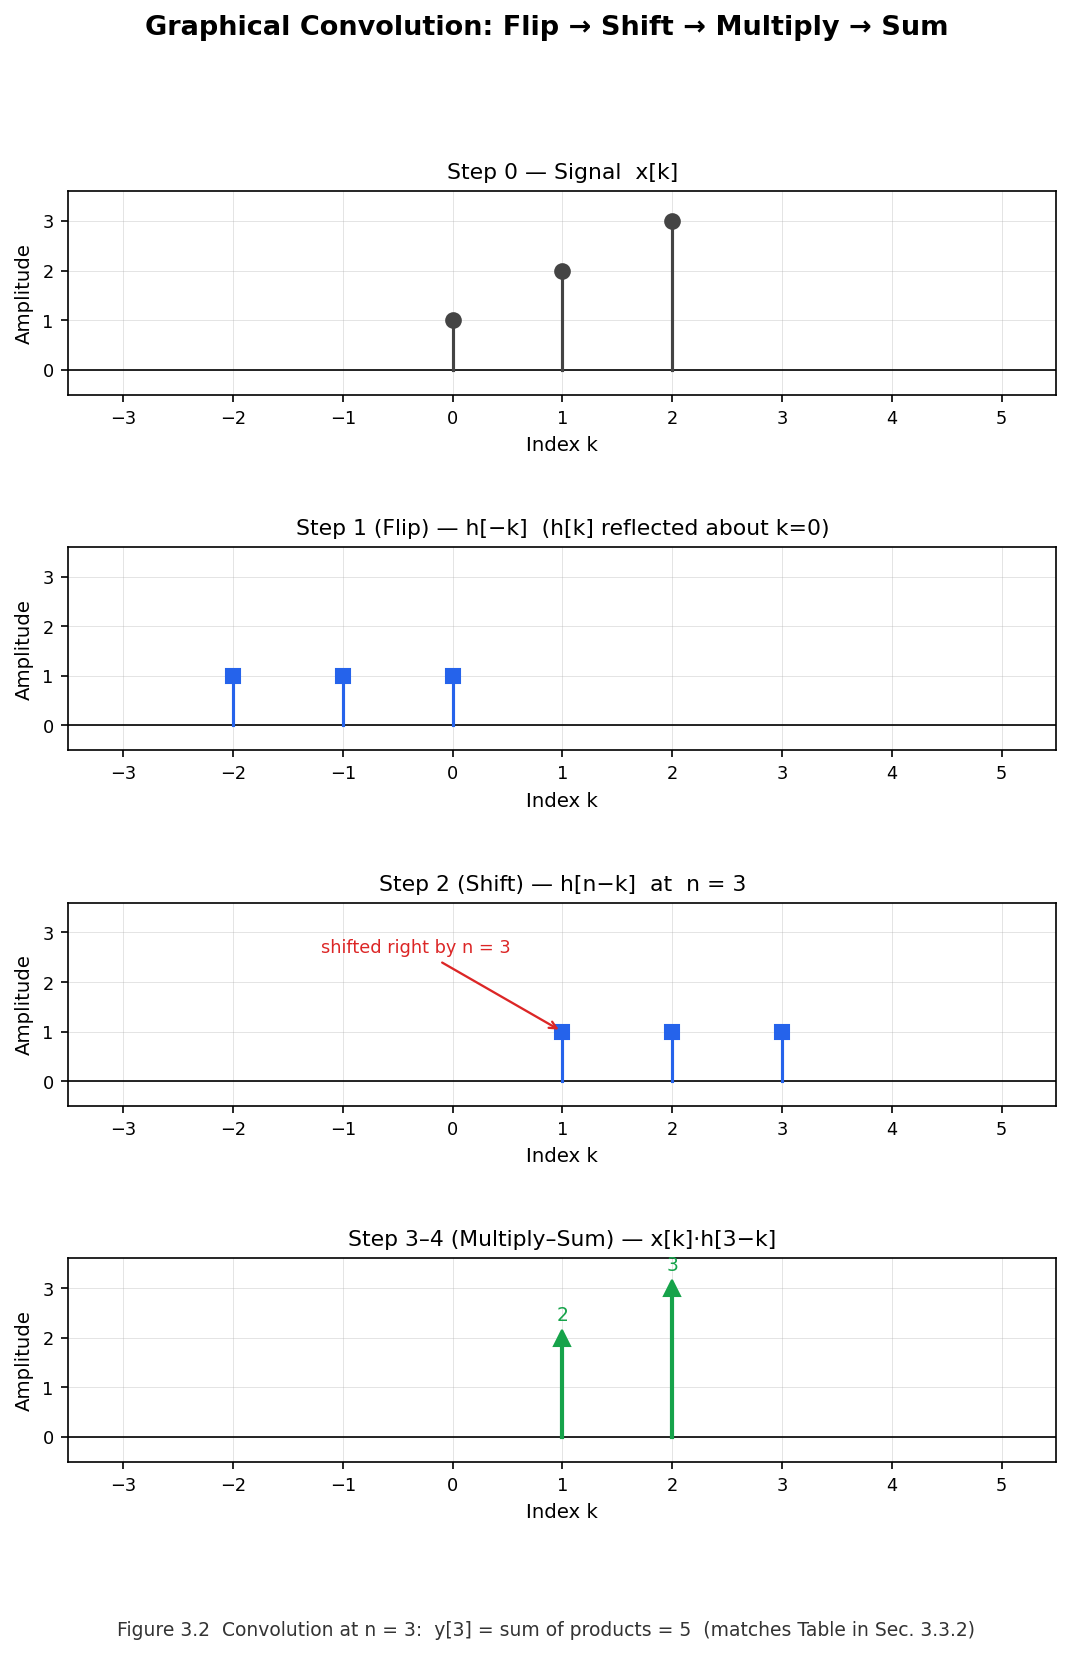</p>

### 3.3.2 수치 예시: 손계산을 통한 검증

$x[n] = \{1, 2, 3\}$ ($n=0,1,2$)와 $h[n] = \{1, 1, 1\}$ ($n=0,1,2$, 길이 3인 이동평균 필터)의 컨볼루션을 계산해 보겠습니다.

| $n$ | 겹치는 $k$의 범위 | 계산 | $y[n]$ |
|---|---|---|---|
| 0 | $k=0$ | $x[0]h[0]$ | $1$ |
| 1 | $k=0,1$ | $x[0]h[1]+x[1]h[0]$ | $3$ |
| 2 | $k=0,1,2$ | $x[0]h[2]+x[1]h[1]+x[2]h[0]$ | $6$ |
| 3 | $k=1,2$ | $x[1]h[2]+x[2]h[1]$ | $5$ |
| 4 | $k=2$ | $x[2]h[2]$ | $3$ |

따라서 $y[n] = \{1, 3, 6, 5, 3\}$입니다. 이 예시는 아래 3.6절 코드에서 그대로 재현하여 검증합니다.

**그림 3.3** 위 표의 시각적 검증


<p align="center">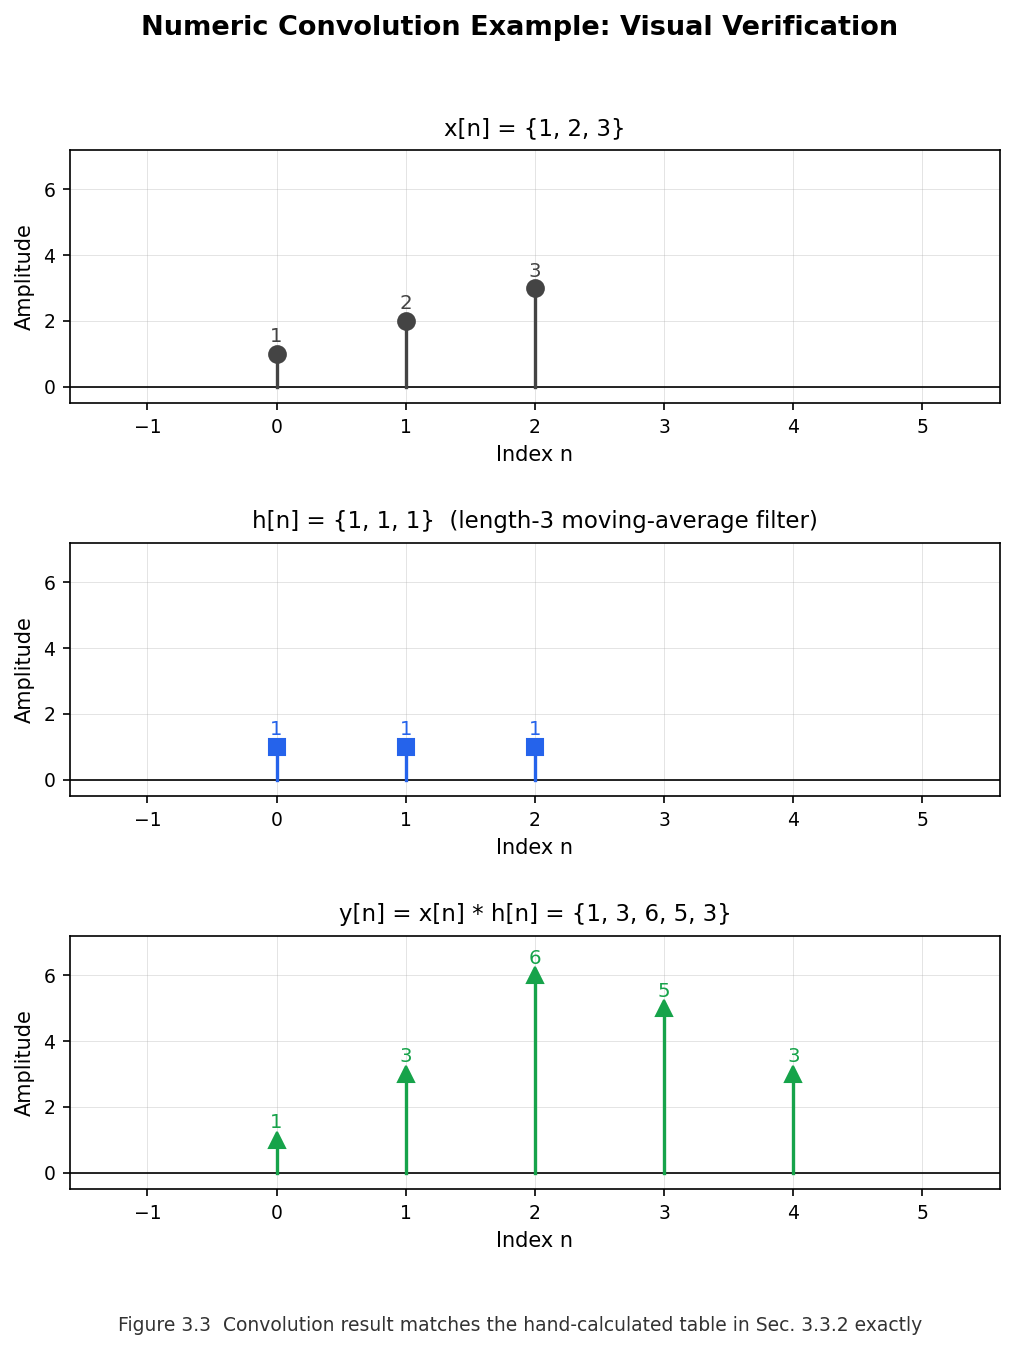</p>

## 3.4 차분방정식과 LTI 시스템

### 3.4.1 선형 상수계수 차분방정식 (LCCDE)

$$
\sum_{i=0}^{N} a_i\, y[n-i] = \sum_{j=0}^{M} b_j\, x[n-j], \qquad a_0 \neq 0 \tag{3.20}
$$

$$
y[n] = \sum_{j=0}^{M} b_j\, x[n-j] - \sum_{i=1}^{N} a_i\, y[n-i] \tag{3.21}
$$

### 3.4.2 FIR 시스템과 IIR 시스템

- **FIR(비재귀)**: 모든 $i\geq1$에 대해 $a_i=0$. 임펄스응답이 유한($M+1$개)합니다: $h[n]=b_n$.
- **IIR(재귀)**: 적어도 하나의 $a_i\,(i\geq1) \neq 0$. 임펄스응답이 일반적으로 무한히 지속됩니다.

**그림 3.4** FIR vs. IIR 블록 다이어그램 — 유일한 차이는 피드백 경로의 유무


<p align="center">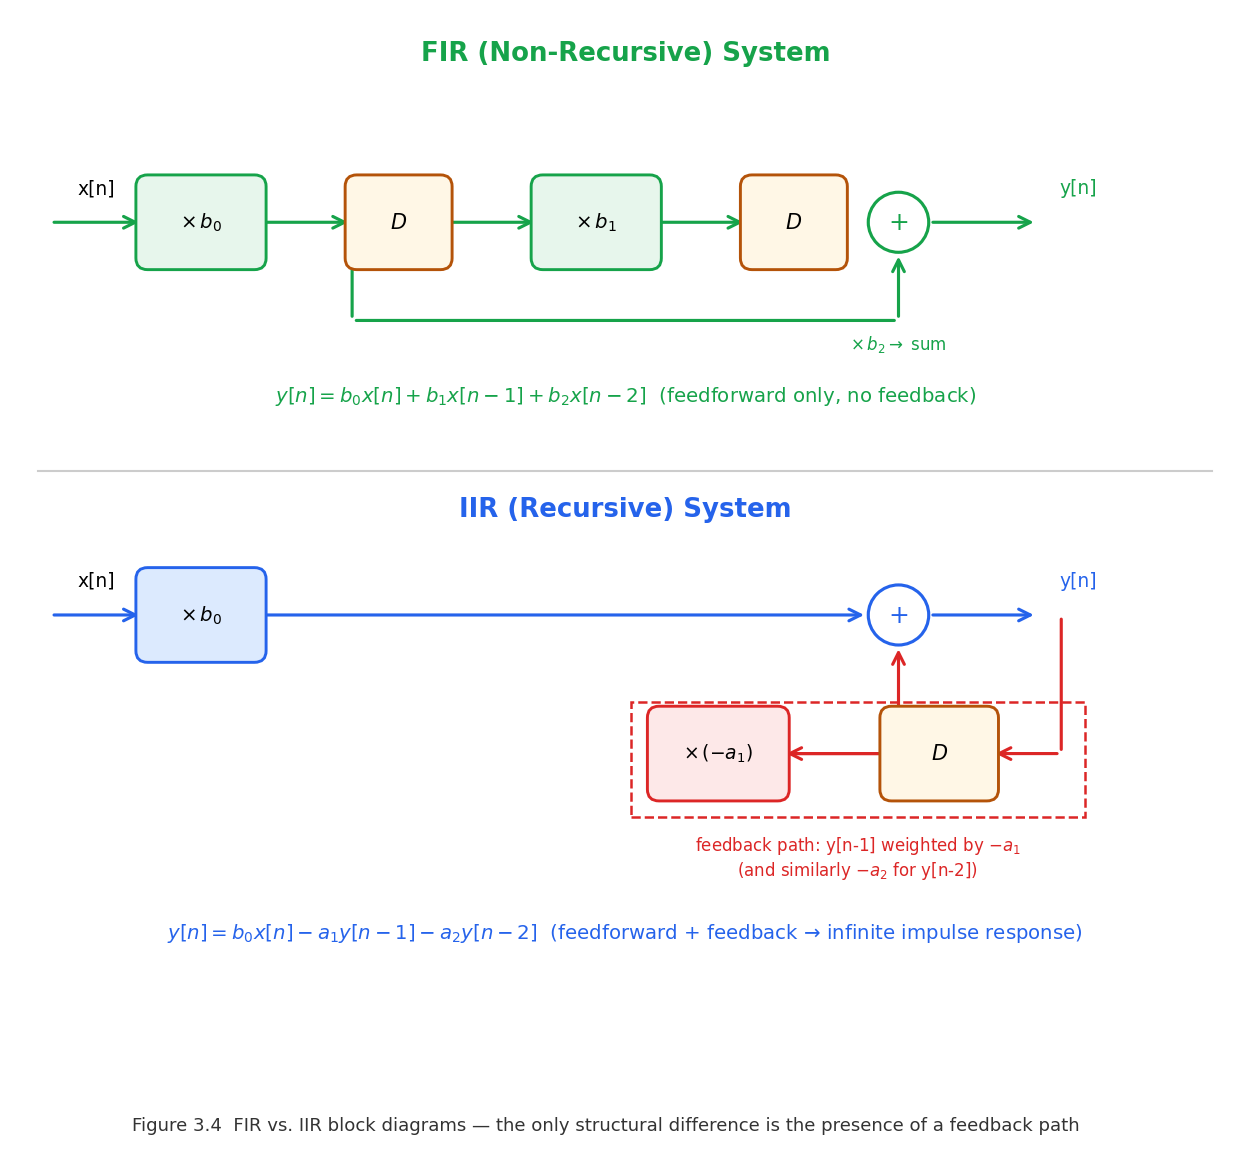</p>

### 3.4.3 수치 예시: 1차 IIR 시스템 (지수 평활, Exponential Smoothing)

$$
y[n] = \alpha\, y[n-1] + (1-\alpha)\,x[n], \qquad 0 < \alpha < 1 \tag{3.23}
$$

초기조건 $y[-1]=0$, $x[n]=\delta[n]$을 대입하면,

$$
h[n] = \alpha^n(1-\alpha)\,u[n] \tag{3.24}
$$

이는 $n\to\infty$에서 점근적으로 0에 가까워질 뿐 완전히 0이 되지 않으므로, 정의 그대로 무한 임펄스응답(IIR)입니다.

**그림 3.5** 1차 IIR 시스템의 무한 임펄스응답 ($\alpha=0.9$)


<p align="center">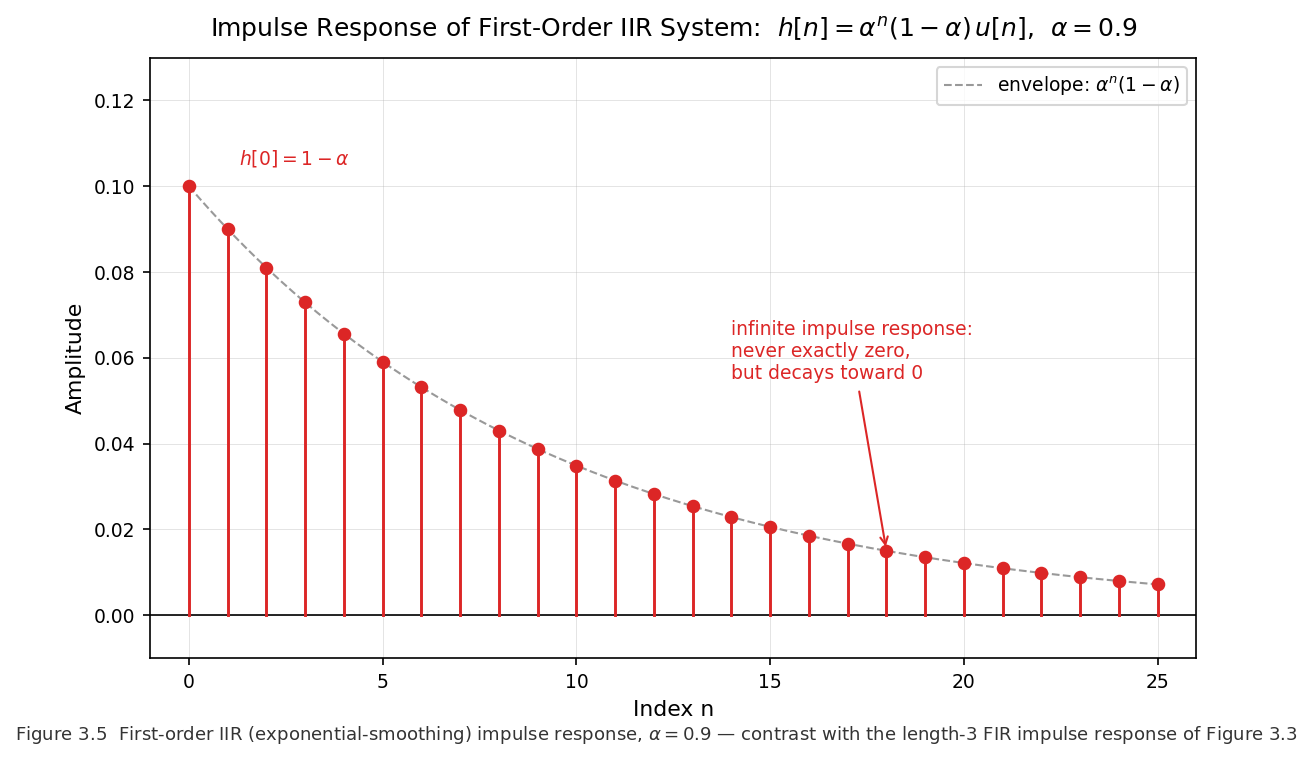</p>

> **참고**: FIR 시스템은 항상 안정적(BIBO stable)이지만, IIR 시스템은 계수 $a_i$의 선택에 따라 불안정해질 수 있습니다. 본 장에서는 (3.23)의 $0<\alpha<1$ 조건이 안정성을 보장한다는 사실만 언급해 둡니다.


## 3.5 핵심 알고리즘: 컨볼루션 합의 직접 계산

**Algorithm 3.1** 컨볼루션 합의 직접 계산 (Direct computation of the convolution sum)

```
Require: x[·] (길이 Nx인 배열), h[·] (길이 Nh인 배열)
Ensure:  y[·] (길이 Ny = Nx+Nh-1인 배열)

1:  SET Ny ← Nx + Nh - 1
2:  FOR i ← 0 TO Ny - 1 DO
3:      SET y[i] ← 0
4:      SET k_min ← max(0, i - Nh + 1)
5:      SET k_max ← min(i, Nx - 1)
6:      FOR k ← k_min TO k_max DO
7:          SET y[i] ← y[i] + x[k]·h[i-k]
8:      ENDFOR
9:  ENDFOR
10: return y[·]
```

각 출력 인덱스 $i$마다 두 배열이 실제로 겹치는 $k$의 범위($k_{\min}=\max(0,i-N_h+1)$ ~ $k_{\max}=\min(i,N_x-1)$)만을 합산하여, 불필요한 영(zero) 곱셈을 반복하지 않습니다. 시간 복잡도는 최악의 경우 $\mathcal{O}(N_x N_h)$입니다.


In [1]:
# 3장 실습에 필요한 라이브러리 설치 (Colab에는 대부분 기본 탑재되어 있음)
!pip install -q numpy scipy matplotlib


In [2]:
"""
3장 예제: 컨볼루션 합의 직접 계산(Algorithm 3.1), 그 결과를 numpy.convolve와 비교 검증,
1차 IIR 차분방정식(지수 평활)의 재귀적 구현과 scipy.signal.lfilter 비교,
그리고 이동평균 필터를 이용한 잡음 신호 평활화 응용까지를 포함한다.
"""

import numpy as np
from scipy import signal
import matplotlib.pyplot as plt


def discrete_convolution(x: np.ndarray, h: np.ndarray, nx0: int = 0, nh0: int = 0):
    """
    Algorithm 3.1을 그대로 구현한 컨볼루션 합 계산 함수.
    x, h: 1차원 배열 (각각 인덱스 nx0, nh0에서 시작한다고 가정)
    반환값: (y, ny0)  y는 결과 배열, ny0는 (3.19)에 따른 y의 시작 인덱스
    """
    Nx = len(x)
    Nh = len(h)
    Ny = Nx + Nh - 1
    ny0 = nx0 + nh0
    y = np.zeros(Ny)
    for i in range(Ny):
        k_min = max(0, i - Nh + 1)
        k_max = min(i, Nx - 1)
        acc = 0.0
        for k in range(k_min, k_max + 1):
            acc += x[k] * h[i - k]
        y[i] = acc
    return y, ny0


def moving_average_filter(M: int) -> np.ndarray:
    """길이 M의 이동평균 필터(FIR 임펄스응답)를 반환한다. h[n] = 1/M, n = 0,...,M-1 (식 3.22)."""
    return np.ones(M) / M


def exponential_smoothing_iir(x: np.ndarray, alpha: float, y_init: float = 0.0) -> np.ndarray:
    """
    1차 IIR 차분방정식 y[n] = alpha*y[n-1] + (1-alpha)*x[n] (식 3.23)을
    재귀적으로 직접 계산한다. y_init은 초기조건 y[-1]에 해당한다.
    """
    y = np.zeros_like(x, dtype=float)
    y_prev = y_init
    for n in range(len(x)):
        y[n] = alpha * y_prev + (1 - alpha) * x[n]
        y_prev = y[n]
    return y

print("함수 정의 완료: discrete_convolution, moving_average_filter, exponential_smoothing_iir")


함수 정의 완료: discrete_convolution, moving_average_filter, exponential_smoothing_iir


In [3]:
# ------------------------------------------------------------------
# (1) 3.3.2절 손계산 예시 검증: x=[1,2,3], h=[1,1,1]
# ------------------------------------------------------------------
x_demo = np.array([1.0, 2.0, 3.0])
h_demo = np.array([1.0, 1.0, 1.0])
y_algo, ny0_demo = discrete_convolution(x_demo, h_demo)
y_ref = np.convolve(x_demo, h_demo, mode='full')

print("=== (1) 컨볼루션 손계산 예시 검증 ===")
print(f"Algorithm 3.1 결과 : {y_algo}  (시작 인덱스 n={ny0_demo})")
print(f"np.convolve 결과   : {y_ref}")
print(f"두 결과 일치 여부   : {np.allclose(y_algo, y_ref)}")


=== (1) 컨볼루션 손계산 예시 검증 ===
Algorithm 3.1 결과 : [1. 3. 6. 5. 3.]  (시작 인덱스 n=0)
np.convolve 결과   : [1. 3. 6. 5. 3.]
두 결과 일치 여부   : True


In [4]:
# ------------------------------------------------------------------
# (2) 1차 IIR 차분방정식: 직접 재귀 계산 vs scipy.signal.lfilter
# ------------------------------------------------------------------
np.random.seed(0)
n = np.arange(0, 200)
fs = 200.0
f0 = 3.0
clean_signal = np.sin(2 * np.pi * f0 * n / fs)
noisy_signal = clean_signal + 0.4 * np.random.randn(len(n))

alpha = 0.9
y_iir_direct = exponential_smoothing_iir(noisy_signal, alpha)
b_coef = [1 - alpha]
a_coef = [1, -alpha]
y_iir_scipy = signal.lfilter(b_coef, a_coef, noisy_signal)

print("=== (2) IIR 차분방정식(지수 평활) 검증 ===")
print(f"직접 재귀 계산과 scipy.signal.lfilter 결과 일치 여부: "
      f"{np.allclose(y_iir_direct, y_iir_scipy)}")


=== (2) IIR 차분방정식(지수 평활) 검증 ===
직접 재귀 계산과 scipy.signal.lfilter 결과 일치 여부: True


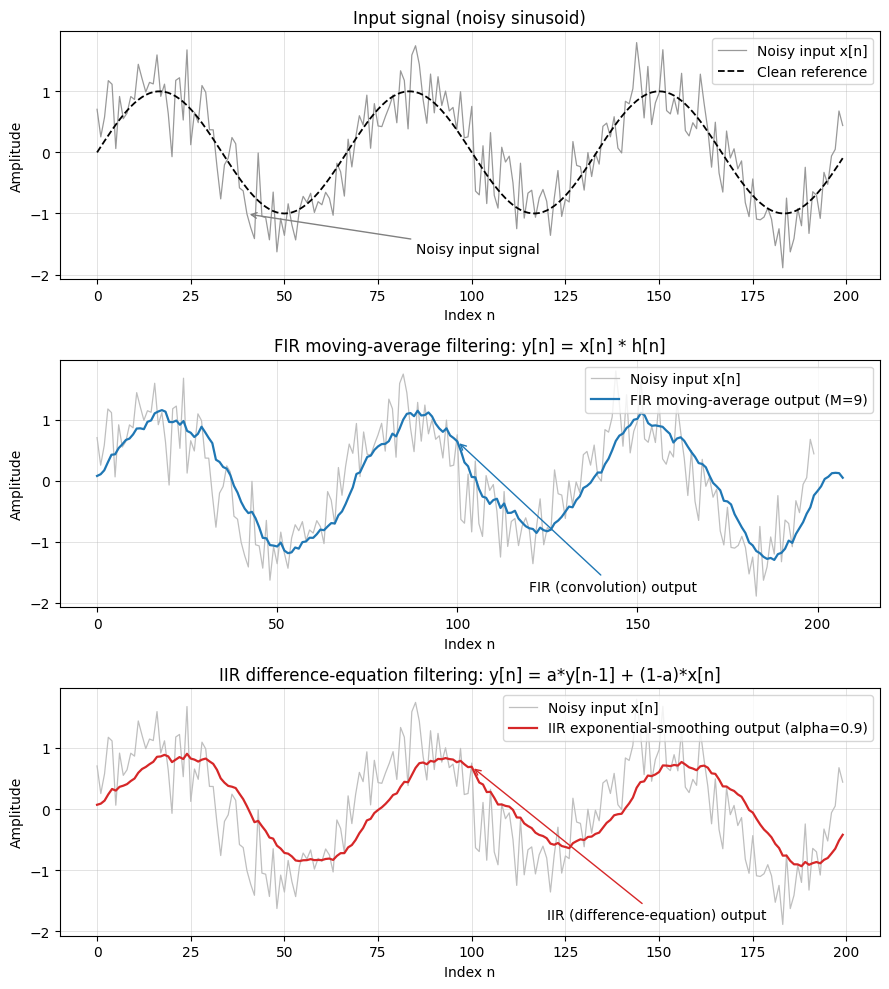

In [5]:
# ------------------------------------------------------------------
# (3) FIR 이동평균 필터를 이용한 잡음 평활화 (3.8절 응용 사례에서 해석)
# ------------------------------------------------------------------
M = 9
h_ma = moving_average_filter(M)
y_ma, ny0_ma = discrete_convolution(noisy_signal, h_ma)
n_ma = np.arange(ny0_ma, ny0_ma + len(y_ma))

# ------------------------------------------------------------------
# (4) 시각화
# ------------------------------------------------------------------
fig, axes = plt.subplots(3, 1, figsize=(9, 10), facecolor='white')
for ax in axes:
    ax.set_facecolor('white')
    ax.grid(True, linewidth=0.5, alpha=0.5)

axes[0].plot(n, noisy_signal, color='0.6', linewidth=0.9, label='Noisy input x[n]')
axes[0].plot(n, clean_signal, color='black', linewidth=1.3, linestyle='--',
             label='Clean reference')
axes[0].set_title('Input signal (noisy sinusoid)')
axes[0].set_xlabel('Index n')
axes[0].set_ylabel('Amplitude')
axes[0].annotate('Noisy input signal', xy=(40, noisy_signal[40]),
                  xytext=(85, -1.65), arrowprops=dict(arrowstyle='->', color='gray'))
axes[0].legend(loc='upper right')

axes[1].plot(n, noisy_signal, color='0.75', linewidth=0.9, label='Noisy input x[n]')
axes[1].plot(n_ma, y_ma, color='tab:blue', linewidth=1.6,
             label=f'FIR moving-average output (M={M})')
axes[1].set_title('FIR moving-average filtering: y[n] = x[n] * h[n]')
axes[1].set_xlabel('Index n')
axes[1].set_ylabel('Amplitude')
axes[1].annotate('FIR (convolution) output', xy=(100, y_ma[100]),
                  xytext=(120, -1.8), arrowprops=dict(arrowstyle='->', color='tab:blue'))
axes[1].legend(loc='upper right')

axes[2].plot(n, noisy_signal, color='0.75', linewidth=0.9, label='Noisy input x[n]')
axes[2].plot(n, y_iir_direct, color='tab:red', linewidth=1.6,
             label=f'IIR exponential-smoothing output (alpha={alpha})')
axes[2].set_title('IIR difference-equation filtering: y[n] = a*y[n-1] + (1-a)*x[n]')
axes[2].set_xlabel('Index n')
axes[2].set_ylabel('Amplitude')
axes[2].annotate('IIR (difference-equation) output', xy=(100, y_iir_direct[100]),
                  xytext=(120, -1.8), arrowprops=dict(arrowstyle='->', color='tab:red'))
axes[2].legend(loc='upper right')

fig.tight_layout()
plt.show()


### 코드 해설

1. **`discrete_convolution`**: Algorithm 3.1의 1~10행을 그대로 옮긴 함수입니다. 합산 구간을 `k_min`, `k_max`로 미리 좁혀서 불필요한 영(zero) 곱셈을 반복하지 않습니다.
2. **`moving_average_filter`**: 길이 $M$의 이동평균 필터 임펄스응답 $h[n]=1/M$을 생성합니다 (식 3.22).
3. **`exponential_smoothing_iir`**: 1차 IIR 차분방정식(식 3.23)을 재귀식 그대로 구현합니다. `scipy.signal.lfilter`와 결과를 비교하여 검증합니다.
4. **검증부 (1)**: 3.3.2절의 손계산 결과 $y[n]=\{1,3,6,5,3\}$이 `discrete_convolution`과 `np.convolve` 양쪽에서 동일하게 나오는지 확인합니다.
5. **검증부 (2)**: 직접 구현한 IIR 재귀 계산과 `scipy.signal.lfilter`의 결과가 부동소수점 오차 범위 내에서 일치하는지 확인합니다.
6. **검증부 (3)과 시각화**: FIR 이동평균 필터(컨볼루션)와 IIR 지수 평활 필터(차분방정식)를 같은 잡음 신호에 적용한 결과를 나란히 비교합니다.

**위 코드 셀을 실행하면 3.7절에서 설명하는 세 개의 부그래프가 실제로 생성됩니다** — 책의 참고 이미지와 자신의 실행 결과를 직접 비교해 보시기 바랍니다.


## 3.7 시각화와 해석 (Visualization and Interpretation)

1. **입력 신호**: $f_0=3$ Hz, $f_s=200$ Hz인 정현파에 표준편차 0.4의 백색잡음을 더한 신호이며, 점선으로 표시된 잡음이 없는 원신호와 비교할 수 있습니다.
2. **FIR(이동평균) 필터링 결과**: 길이 9인 이동평균 필터로 컨볼루션한 결과로, 잡음의 빠른 변동이 평균화되어 줄어들었지만 신호 자체도 약간 매끄러워지면서 진폭이 일부 감소하는 모습을 볼 수 있습니다. 이는 이동평균 필터가 저역통과(low-pass) 특성을 가진다는 사실(9장에서 엄밀하게 다룸)을 시간영역에서 미리 확인하는 것에 해당합니다.
3. **IIR(지수 평활) 필터링 결과**: $\alpha=0.9$로 설정한 1차 IIR 필터의 결과이며, FIR 결과와 유사하게 잡음이 평활화되지만, 출력이 과거 출력에 재귀적으로 의존하기 때문에 신호의 변화에 더 느리게 반응하는(지연이 더 큰) 경향을 관찰할 수 있습니다.

FIR와 IIR 두 결과의 가장 본질적인 차이는, FIR 필터는 유한한 개수(9개)의 과거 입력만을 사용하므로 출력이 항상 유한한 "메모리" 안에서 결정되는 반면, IIR 필터는 이론적으로 무한히 먼 과거의 입력까지 모두 (지수적으로 감쇄하는 가중치로) 반영한다는 점입니다. 이 차이는 9~10장에서 FIR/IIR 필터를 설계할 때 선택의 기준이 되는 핵심적인 트레이드오프로 다시 등장합니다.


## 3.8 응용 사례 (Application Case)

3.6절에서 다룬 이동평균 필터는, 측정 잡음이 포함된 거의 모든 실세계 신호에 대한 가장 기본적인 전처리(preprocessing) 도구로 사용됩니다. 예를 들어 생체신호 중 ECG(심전도)는 측정 과정에서 호흡이나 전극의 미세한 움직임으로 인한 저주파 변동, 즉 **베이스라인 표류(baseline wander)**가 섞여 들어가는 경우가 매우 흔합니다. 본 장에서 다룬 컨볼루션 기반 필터링의 원리는 이러한 베이스라인 표류를 제거하는 작업의 이론적 토대가 되며, 구체적인 구현은 [응용 모듈 A] ECG 베이스라인 표류 검출에서 본격적으로 다룹니다.


## 3.9 연습문제 (Exercises)

**이론형**

1. $x[n] = \{2, -1, 3\}$ ($n=0,1,2$)와 $h[n] = \{1, 0, -1\}$ ($n=0,1,2$)의 컨볼루션 $y[n]=x[n]*h[n]$을 표 작성법을 이용하여 손으로 계산하고, 결과의 길이가 식(3.19)와 일치하는지 확인하라.
2. 차분방정식 $y[n] = 0.5\,y[n-1] + x[n] - x[n-1]$로 기술되는 시스템이 FIR인지 IIR인지 판별하고, 그 근거를 서술하라.

**코딩형 1**: 아래 셀의 함수를 완성하라.


In [6]:
def first_difference_filter(x: np.ndarray) -> np.ndarray:
    """
    차분방정식 y[n] = x[n] - x[n-1] (1차 차분기, first-difference filter)을
    discrete_convolution 함수를 호출하여 구현하라. (즉 h[n]에 해당하는
    배열을 직접 구성한 뒤 discrete_convolution(x, h)를 호출할 것.)
    """
    # TODO: 구현
    pass

# 아래 주석을 해제하여 구현을 테스트해 보세요.
# test_x = np.array([1.0, 3.0, 6.0, 5.0, 3.0])
# print(first_difference_filter(test_x))


**코딩형 2**: `discrete_convolution` 함수의 이중 반복문 구조를 그대로 유지한 채, 누적 합산 부분(Algorithm 3.1의 6~8행)만 `numpy`의 벡터 연산(슬라이싱)으로 대체하여 더 빠르게 동작하도록 수정하고, 원래 구현과 결과가 동일한지 비교하라.


In [7]:
def discrete_convolution_vectorized(x: np.ndarray, h: np.ndarray, nx0: int = 0, nh0: int = 0):
    """
    discrete_convolution과 동일한 인터페이스를 갖되, 내부 누적 합산을
    numpy 벡터 연산(슬라이싱)으로 대체한 버전. (연습문제 2 정답 예시는 비워둠)
    """
    # TODO: 구현
    pass

# 아래 주석을 해제하여 원래 구현과 결과를 비교해 보세요.
# y_vec, _ = discrete_convolution_vectorized(x_demo, h_demo)
# print(np.allclose(y_vec, y_algo))


## 참고문헌 (References)

1. 이철희. (2016). 『디지털 신호처리(2판)』. 한빛아카데미.
2. Oppenheim, A. V., & Willsky, A. S. (1996). *Signals and Systems* (2nd ed.). Prentice Hall.
3. Proakis, J. G., & Manolakis, D. G. (2006). *Digital Signal Processing: Principles, Algorithms, and Applications* (4th ed.). Prentice Hall.
4. Harris, C. R., et al. (2020). Array programming with NumPy. *Nature*, 585, 357–362.
5. Virtanen, P., et al. (2020). SciPy 1.0: fundamental algorithms for scientific computing in Python. *Nature Methods*, 17, 261–272.

---

*이 노트북은 「파이썬 기반 신호처리 교재 구성안」을 기준으로 `3장_컨볼루션과_차분방정식_v7.md`를 Colab 호환 형식으로 변환하여 작성되었습니다. 그림 3.1~3.5는 `3장_figures/`의 실제 생성 이미지를 base64로 임베드하였으며, 3.6절 코드 실행 시 3.7절의 결과 그래프가 노트북 안에서 직접 재현됩니다.*
